In [1]:
pip install yfinance pandas numpy matplotlib tensorflow keras gym finrl scipy arch

  Using cached keras-3.8.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached gym-0.26.2.tar.gz (721 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.1.24-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-2.5.0-py3-none-any.whl.metadata (6.1 kB)
  Using cached namex-0.0.8-py3-none-any.whl.metadata (246 bytes)
  Using cac

  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/ElegantRL.git 'C:\Users\jini\AppData\Local\Temp\pip-install-2fhtcqva\elegantrl_14d5fb392ff6485aba881d996192014a'
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [25]:
import numpy as np
import pandas as pd

# Calculate ROI (Return on Investment)
def calculate_roi(data):
    initial_price = data['Close'].iloc[0]
    final_price = data['Close'].iloc[-1]
    roi = (final_price - initial_price) / initial_price
    return roi

# Calculate Absolute Returns
def calculate_absolute_returns(data):
    initial_price = data['Close'].iloc[0]
    final_price = data['Close'].iloc[-1]
    absolute_return = final_price - initial_price
    return absolute_return

# Compare against market benchmarks
def compare_returns(stock_data, benchmark_data):
    stock_roi = calculate_roi(stock_data)
    stock_absolute_return = calculate_absolute_returns(stock_data)
    
    benchmark_roi = {index: calculate_roi(benchmark_data[index]) for index in benchmark_data}
    benchmark_absolute_return = {index: calculate_absolute_returns(benchmark_data[index]) for index in benchmark_data}
    
    comparison = {
        'Metric': ['ROI', 'Absolute Return'],
        'Stock': [stock_roi, stock_absolute_return],
        'S&P 500': [benchmark_roi['^GSPC'], benchmark_absolute_return['^GSPC']],
        'NASDAQ': [benchmark_roi['^IXIC'], benchmark_absolute_return['^IXIC']],
        'Dow Jones': [benchmark_roi['^DJI'], benchmark_absolute_return['^DJI']]
    }
    return pd.DataFrame(comparison)

# Example usage
stock_ticker = 'AAPL'
market_indices = ['^GSPC', '^IXIC', '^DJI']  # S&P 500, NASDAQ, Dow Jones
start_date = '2015-01-01'
end_date = '2023-01-01'

# Fetch data
stock_data = fetch_data(stock_ticker, start_date, end_date)
benchmark_data = {index: fetch_data(index, start_date, end_date) for index in market_indices}

# Compare returns
returns_comparison = compare_returns(stock_data, benchmark_data)
print("Returns Comparison:")
print(returns_comparison)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Returns Comparison:
            Metric                                     Stock  \
0              ROI    Ticker
AAPL    4.281017
dtype: float64   
1  Absolute Return  Ticker
AAPL    104.230688
dtype: float64   

                                      S&P 500  \
0     Ticker
^GSPC    0.865465
dtype: float64   
1  Ticker
^GSPC    1781.300049
dtype: float64   

                                      NASDAQ  \
0     Ticker
^IXIC    1.21428
dtype: float64   
1  Ticker
^IXIC    5739.67041
dtype: float64   

                                    Dow Jones  
0       Ticker
^DJI    0.85876
dtype: float64  
1  Ticker
^DJI    15314.259766
dtype: float64  


In [33]:
import yfinance as yf
import pandas as pd
import numpy as np

# Fetch data
def fetch_data(ticker, start_date, end_date):
    data = yf.download(ticker, start=start_date, end=end_date)
    return data

# Preprocess data
def preprocess_data(data):
    data['Daily Return'] = data['Close'].pct_change()
    data['Normalized Close'] = (data['Close'] - data['Close'].min()) / (data['Close'].max() - data['Close'].min())
    return data.dropna()

# Define stock and market indices
stock_ticker = 'AAPL'
market_indices = ['^GSPC', '^IXIC', '^DJI']  # S&P 500, NASDAQ, Dow Jones
start_date = '2015-01-01'
end_date = '2023-01-01'

# Fetch and preprocess data
stock_data = fetch_data(stock_ticker, start_date, end_date)
stock_data = preprocess_data(stock_data)

# Fetch and preprocess market indices data
market_data = {}
for index in market_indices:
    data = fetch_data(index, start_date, end_date)
    market_data[index] = preprocess_data(data)

# Display preprocessed data
print(stock_data.head())

# Define criteria for above and under-market profits and returns
def calculate_metrics(data, benchmark_data):
    data['Cumulative Return'] = (1 + data['Daily Return']).cumprod()
    benchmark_data['Cumulative Return'] = (1 + benchmark_data['Daily Return']).cumprod()
    
    metrics = {
        'Absolute Return': data['Cumulative Return'].iloc[-1] - 1,
        'Benchmark Return': benchmark_data['Cumulative Return'].iloc[-1] - 1,
        'ROI': data['Cumulative Return'].iloc[-1] / benchmark_data['Cumulative Return'].iloc[-1] - 1
    }
    return metrics

# Compare against market benchmarks
for index, data in market_data.items():
    metrics = calculate_metrics(stock_data, data)
    print(f"Metrics for {stock_ticker} compared to {index}:")
    for key, value in metrics.items():
        print(f"{key}: {value:.2f}")

# Map out potential risks associated with stock trading
def identify_risks():
    risks = {
        'Market Crashes': 'Significant declines in market value.',
        'Liquidity Risks': 'Challenges in buying or selling assets without affecting the price.',
        'Technical Risks': 'Failures in trading algorithms or technical infrastructure.'
    }
    return risks

risks = identify_risks()
print("Potential Risks:")
for risk, description in risks.items():
    print(f"{risk}: {description}")

# Research real-world financial regulations
def financial_regulations():
    regulations = {
        'Basel III': 'International regulatory framework for banks focusing on risk management.',
        'Dodd-Frank Act': 'US regulation to promote financial stability and protect consumers.'
    }
    return regulations

regulations = financial_regulations()
print("Financial Regulations:")
for regulation, description in regulations.items():
    print(f"{regulation}: {description}")

# Identify and document quantitative parameters involved in risk management calculations
def risk_metrics():
    metrics = {
        'Value at Risk (VaR)': 'A measure of the potential loss in value of a portfolio.',
        'Conditional Value at Risk (CVaR)': 'The expected loss exceeding the VaR threshold.',
        'Expected Shortfall (ES)': 'The average of the losses that occur beyond the VaR.'
    }
    return metrics

risk_metrics = risk_metrics()
print("Risk Management Metrics:")
for metric, description in risk_metrics.items():
    print(f"{metric}: {description}")



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume  \
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL   
Date                                                                
2015-01-05  23.661272  24.195739  23.474210  24.115569  257142000   
2015-01-06  23.663502  23.924054  23.300509  23.725856  263188400   
2015-01-07  23.995312  24.095523  23.761482  23.872829  160423600   
2015-01-08  24.917271  24.975172  24.206875  24.324905  237458000   
2015-01-09  24.943993  25.220133  24.543142  25.090970  214798000   

Price      Daily Return Normalized Close  
Ticker                                    
Date                                      
2015-01-05    -0.028172         0.018715  
2015-01-06     0.000094         0.018729  
2015-01-07     0.014022         0.020824  
2015-01-08     0.038422         0.026645  
2015-01-09     0.001072         0.026814  
Metrics for AAPL compared to ^GSPC:
Absolute Return: 4.28
Benchmark Return: 0.87
ROI: 1.83
Metrics for 

In [39]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fetch data
def fetch_data(ticker, start_date, end_date):
    data = yf.download(ticker, start=start_date, end=end_date)
    return data

# Preprocess data
def preprocess_data(data):
    data['Daily Return'] = data['Close'].pct_change()
    data['Normalized Close'] = (data['Close'] - data['Close'].min()) / (data['Close'].max() - data['Close'].min())
    return data.dropna()

# Define stock and market indices
stock_ticker = 'AAPL'
market_indices = ['^GSPC', '^IXIC', '^DJI']  # S&P 500, NASDAQ, Dow Jones
start_date = '2015-01-01'
end_date = '2023-01-01'

# Fetch and preprocess data
stock_data = fetch_data(stock_ticker, start_date, end_date)
stock_data = preprocess_data(stock_data)

# Fetch and preprocess market indices data
market_data = {}
for index in market_indices:
    data = fetch_data(index, start_date, end_date)
    market_data[index] = preprocess_data(data)

# Define criteria for above and under-market profits and returns
def calculate_metrics(data, benchmark_data):
    data['Cumulative Return'] = (1 + data['Daily Return']).cumprod()
    benchmark_data['Cumulative Return'] = (1 + benchmark_data['Daily Return']).cumprod()
    
    metrics = {
        'Absolute Return': data['Cumulative Return'].iloc[-1] - 1,
        'Benchmark Return': benchmark_data['Cumulative Return'].iloc[-1] - 1,
        'ROI': data['Cumulative Return'].iloc[-1] / benchmark_data['Cumulative Return'].iloc[-1] - 1
    }
    return metrics



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [41]:
# Compare against market benchmarks
for index, data in market_data.items():
    metrics = calculate_metrics(stock_data, data)
    print(f"Metrics for {stock_ticker} compared to {index}:")
    for key, value in metrics.items():
        print(f"{key}: {value:.2f}")



Metrics for AAPL compared to ^GSPC:
Absolute Return: 4.28
Benchmark Return: 0.87
ROI: 1.83
Metrics for AAPL compared to ^IXIC:
Absolute Return: 4.28
Benchmark Return: 1.21
ROI: 1.38
Metrics for AAPL compared to ^DJI:
Absolute Return: 4.28
Benchmark Return: 0.86
ROI: 1.84


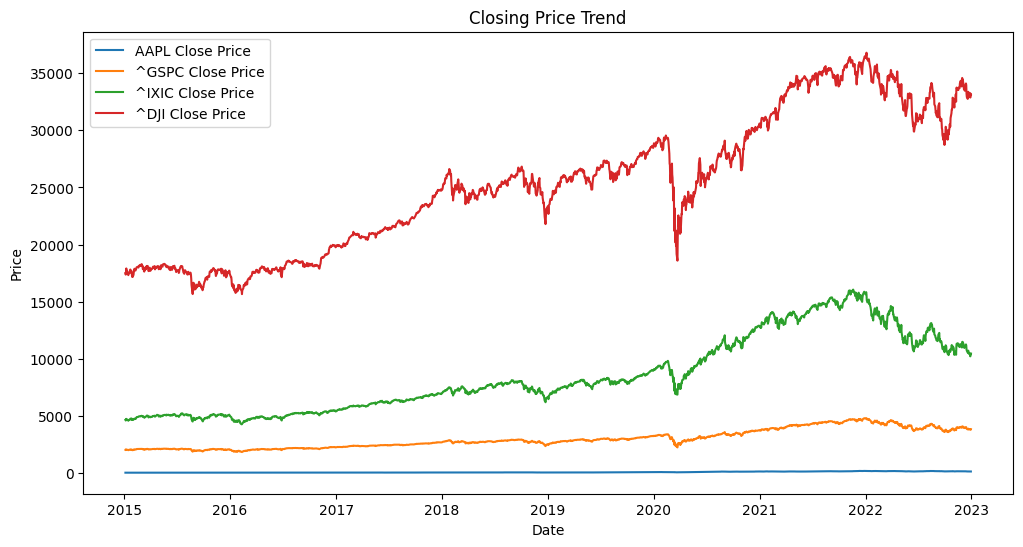

In [43]:
# Plot Closing Price Trend
plt.figure(figsize=(12, 6))
plt.plot(stock_data['Close'], label=f'{stock_ticker} Close Price')
for index, data in market_data.items():
    plt.plot(data['Close'], label=f'{index} Close Price')
plt.title('Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()



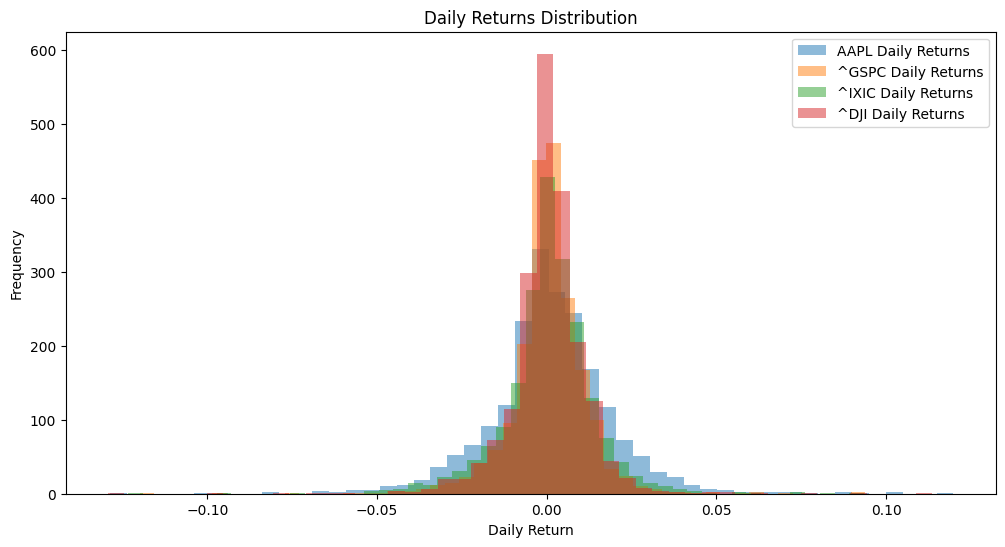

In [45]:
# Plot Daily Returns Histogram
plt.figure(figsize=(12, 6))
plt.hist(stock_data['Daily Return'], bins=50, alpha=0.5, label=f'{stock_ticker} Daily Returns')
for index, data in market_data.items():
    plt.hist(data['Daily Return'], bins=50, alpha=0.5, label=f'{index} Daily Returns')
plt.title('Daily Returns Distribution')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.legend()
plt.show()



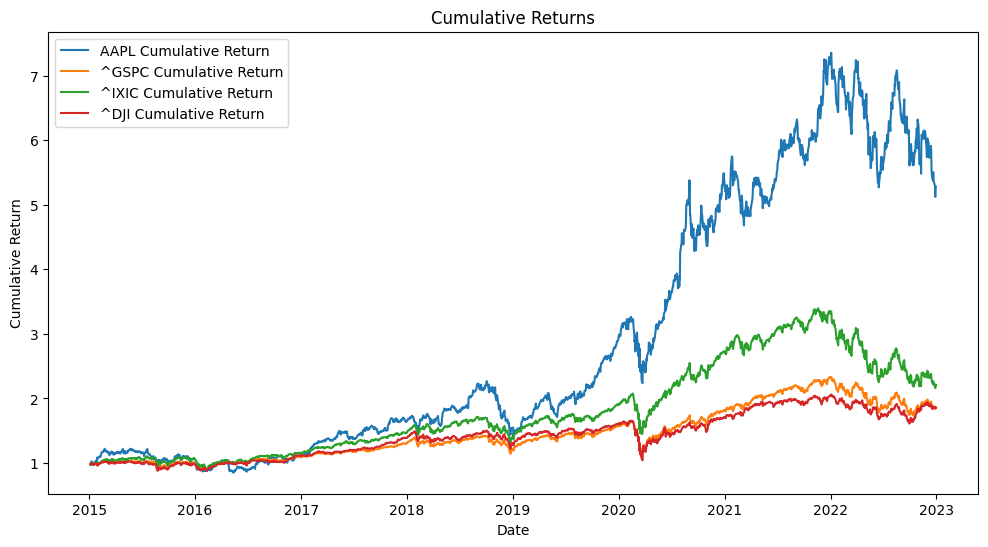

In [47]:
# Plot Cumulative Returns
plt.figure(figsize=(12, 6))
plt.plot(stock_data['Cumulative Return'], label=f'{stock_ticker} Cumulative Return')
for index, data in market_data.items():
    plt.plot(data['Cumulative Return'], label=f'{index} Cumulative Return')
plt.title('Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()




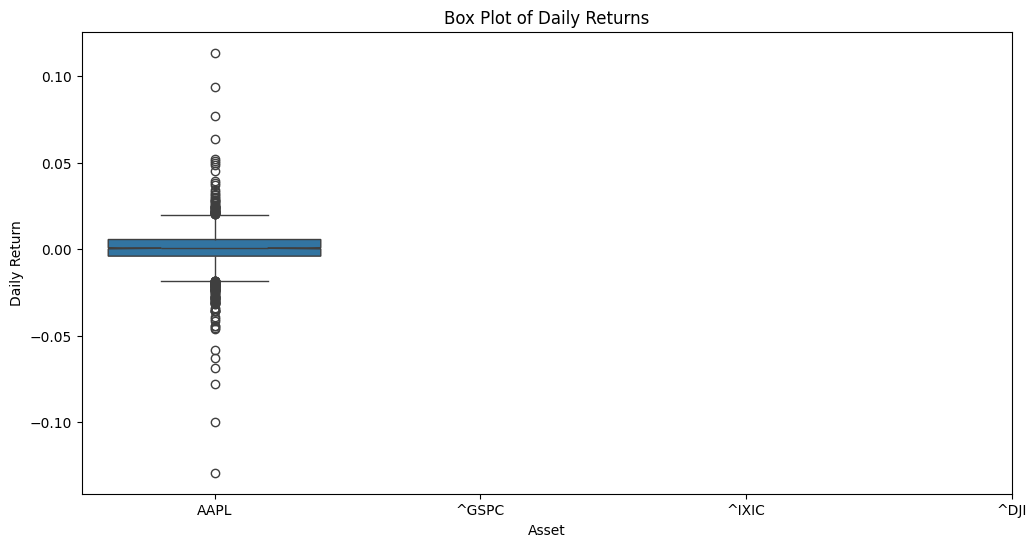

In [49]:
# Box Plot of Daily Returns
plt.figure(figsize=(12, 6))
sns.boxplot(data=[stock_data['Daily Return']] + [market_data[index]['Daily Return'] for index in market_indices], notch=True)
plt.xticks(ticks=range(len(market_indices) + 1), labels=[stock_ticker] + market_indices)
plt.title('Box Plot of Daily Returns')
plt.xlabel('Asset')
plt.ylabel('Daily Return')
plt.show()



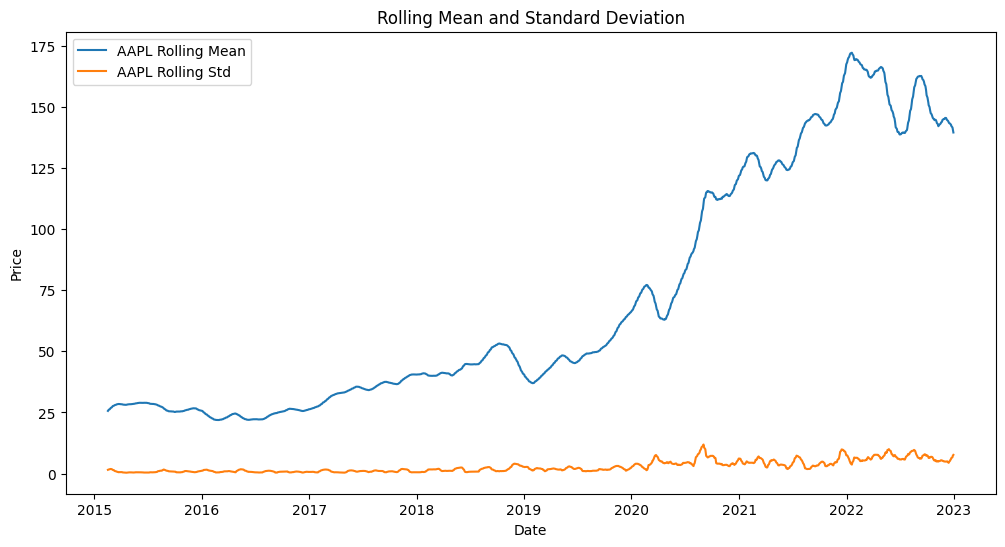

In [51]:
# Rolling Mean and Standard Deviation
window = 30
plt.figure(figsize=(12, 6))
plt.plot(stock_data['Close'].rolling(window).mean(), label=f'{stock_ticker} Rolling Mean')
plt.plot(stock_data['Close'].rolling(window).std(), label=f'{stock_ticker} Rolling Std')
plt.title('Rolling Mean and Standard Deviation')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()



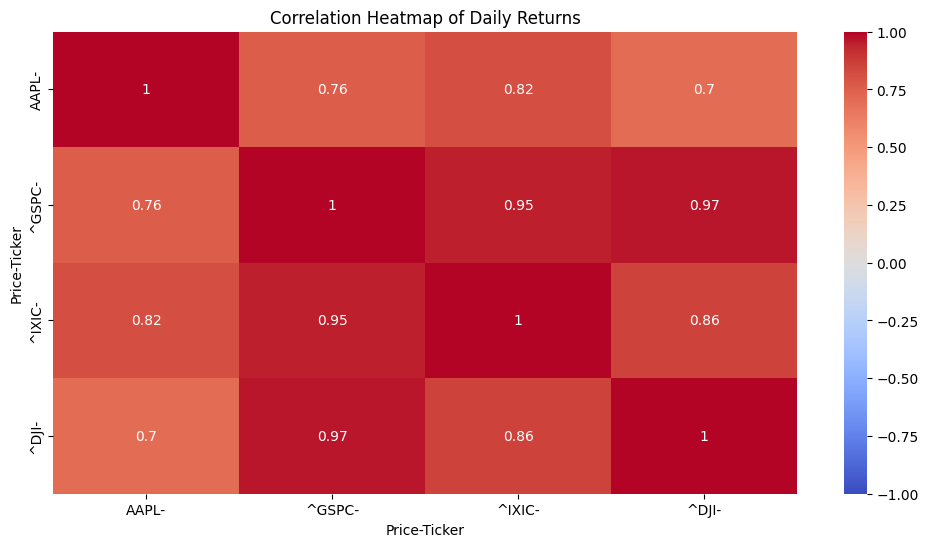

In [53]:
# Correlation Heatmap
all_data = stock_data[['Daily Return']].rename(columns={'Daily Return': stock_ticker})
for index, data in market_data.items():
    all_data[index] = data['Daily Return']

plt.figure(figsize=(12, 6))
sns.heatmap(all_data.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Daily Returns')
plt.show()

In [69]:
import pandas as pd
import numpy as np

# Moving Average Crossover Strategy
def moving_average_crossover(data, short_window=40, long_window=100):
    signals = pd.DataFrame(index=data.index)
    signals['Signal'] = 0.0

    # Create short and long moving averages
    signals['Short_MA'] = data['Close'].rolling(window=short_window, min_periods=1).mean()
    signals['Long_MA'] = data['Close'].rolling(window=long_window, min_periods=1).mean()

    # Generate signals using .iloc for positional indexing
    signals.iloc[short_window:, signals.columns.get_loc('Signal')] = np.where(
        signals['Short_MA'].iloc[short_window:] > signals['Long_MA'].iloc[short_window:], 1.0, 0.0
    )
    
    # Calculate positions (1 for buy, -1 for sell, 0 for hold)
    signals['Position'] = signals['Signal'].diff()

    return signals

# Apply Moving Average Crossover
signals = moving_average_crossover(stock_data)
print(signals.tail())

            Signal    Short_MA     Long_MA  Position
Date                                                
2022-12-23     0.0  142.262933  148.782387       0.0
2022-12-27     0.0  141.633252  148.433300       0.0
2022-12-28     0.0  140.964137  148.047001       0.0
2022-12-29     0.0  140.449784  147.700772       0.0
2022-12-30     0.0  140.082154  147.357216       0.0


In [71]:
from scipy.stats import norm

# Calculate Value at Risk (VaR)
def calculate_var(data, confidence_level=0.95):
    daily_returns = data['Daily Return'].dropna()
    var = np.percentile(daily_returns, (1 - confidence_level) * 100)
    return var

# Calculate Expected Shortfall (ES)
def calculate_es(data, confidence_level=0.95):
    daily_returns = data['Daily Return'].dropna()
    var = calculate_var(data, confidence_level)
    es = daily_returns[daily_returns <= var].mean()
    return es

# Calculate VaR and ES
var = calculate_var(stock_data)
es = calculate_es(stock_data)
print(f"VaR: {var}, ES: {es}")

VaR: -0.028885044812372168, ES: -0.04309179209439423


In [59]:
import tensorflow as tf
from collections import deque
import random

class DQN:
    def __init__(self, state_dim, action_dim):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.model = self.build_model()

    def build_model(self):
        model = tf.keras.Sequential([
            layers.Dense(24, input_dim=self.state_dim, activation='relu'),
            layers.Dense(24, activation='relu'),
            layers.Dense(self.action_dim, activation='linear')
        ])
        model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))
        return model

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_dim)
        q_values = self.model.predict(state)
        return np.argmax(q_values[0])

    def train(self, batch_size):
        if len(self.memory) < batch_size:
            return
        minibatch = random.sample(self.memory, batch_size)
        states = np.array([i[0] for i in minibatch])
        actions = np.array([i[1] for i in minibatch])
        rewards = np.array([i[2] for i in minibatch])
        next_states = np.array([i[3] for i in minibatch])
        dones = np.array([i[4] for i in minibatch])

        targets = rewards + self.gamma * (np.amax(self.model.predict(next_states), axis=1)) * (1 - dones)
        target_f = self.model.predict(states)
        for i, action in enumerate(actions):
            target_f[i][action] = targets[i]
        self.model.fit(states, target_f, epochs=1, verbose=0)

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

In [61]:
class PolicyGradient:
    def __init__(self, state_dim, action_dim):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.model = self.build_model()

    def build_model(self):
        model = tf.keras.Sequential([
            layers.Dense(24, input_dim=self.state_dim, activation='relu'),
            layers.Dense(24, activation='relu'),
            layers.Dense(self.action_dim, activation='softmax')
        ])
        model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.01))
        return model

    def act(self, state):
        probs = self.model.predict(state)
        return np.random.choice(self.action_dim, p=probs[0])

In [63]:
# Monte Carlo Simulation for Portfolio Optimization
def monte_carlo_portfolio_simulation(returns, num_simulations=1000):
    portfolio_returns = []
    for _ in range(num_simulations):
        weights = np.random.random(len(returns.columns))
        weights /= np.sum(weights)
        portfolio_return = np.dot(returns.mean(), weights)
        portfolio_returns.append(portfolio_return)
    return np.array(portfolio_returns)

# Example usage
returns = stock_data[['Daily Return']]  # Replace with multiple assets
portfolio_returns = monte_carlo_portfolio_simulation(returns)
print(f"Mean Portfolio Return: {np.mean(portfolio_returns)}")

Mean Portfolio Return: 0.0010049943392338933


In [65]:
from arch import arch_model

# GARCH Model
def garch_model(data):
    model = arch_model(data['Daily Return'], vol='Garch', p=1, q=1)
    results = model.fit()
    return results

# Fit GARCH model
garch_results = garch_model(stock_data)
print(garch_results.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 6305051888.620241
Iteration:      2,   Func. Count:     19,   Neg. LLF: 1.7531456977123016e+16
Iteration:      3,   Func. Count:     30,   Neg. LLF: -5343.324349443137
Optimization terminated successfully    (Exit mode 0)
            Current function value: -5343.324344376553
            Iterations: 7
            Function evaluations: 30
            Gradient evaluations: 3
                     Constant Mean - GARCH Model Results                      
Dep. Variable:           Daily Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                5343.32
Distribution:                  Normal   AIC:                          -10678.6
Method:            Maximum Likelihood   BIC:                          -10656.2
                                        No. Observations:                 2013
Date:            

C:\Users\jini\anaconda3\envs\tradingbot3.11\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003557. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


In [67]:
# Stress Testing
def stress_test(data, crash_percentage=0.2):
    crash_data = data.copy()
    crash_data['Close'] = crash_data['Close'] * (1 - crash_percentage)
    return crash_data

# Simulate a 20% market crash
crash_data = stress_test(stock_data)
print(crash_data.head())

Price           Close       High        Low       Open     Volume  \
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL   
Date                                                                
2015-01-05  18.929018  24.195739  23.474210  24.115569  257142000   
2015-01-06  18.930801  23.924054  23.300509  23.725856  263188400   
2015-01-07  19.196249  24.095523  23.761482  23.872829  160423600   
2015-01-08  19.933817  24.975172  24.206875  24.324905  237458000   
2015-01-09  19.955194  25.220133  24.543142  25.090970  214798000   

Price      Daily Return Normalized Close Cumulative Return  
Ticker                                                      
Date                                                        
2015-01-05    -0.028172         0.018715          0.971828  
2015-01-06     0.000094         0.018729          0.971920  
2015-01-07     0.014022         0.020824          0.985548  
2015-01-08     0.038422         0.026645          1.023415  
2015-01-09     0.001